In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import shutil
import numpy as np
from scipy.signal import find_peaks

In [50]:
from pathlib import Path

rutas = list(Path(r"C:\Program Files").glob("**/gswin64c.exe"))
rutas += list(Path(r"C:\Program Files (x86)").glob("**/gswin64c.exe"))

print(rutas)

[WindowsPath('C:/Program Files/gs/gs10.07.0/bin/gswin64c.exe')]


In [51]:
import shutil
print(shutil.which("gswin64c"))

C:\Program Files\gs\gs10.07.0\bin\gswin64c.EXE


In [52]:
from pathlib import Path
import subprocess
import shutil

archivo_ps = Path("ThArR580.ps")
archivo_pdf = Path("ThArR580.pdf")

gs = shutil.which("gswin64c")

subprocess.run([
    gs,
    "-sDEVICE=pdfwrite",
    "-o", str(archivo_pdf),
    str(archivo_ps)
], check=True)

print("PDF creado:", archivo_pdf.resolve())

PDF creado: C:\Users\Vanessa\OneDrive - Universidad de los andes\Escritorio\UNIANDES SEMESTRE 7\PROYECTO EXPERIMENTAL\HD49331\ThArR580.pdf


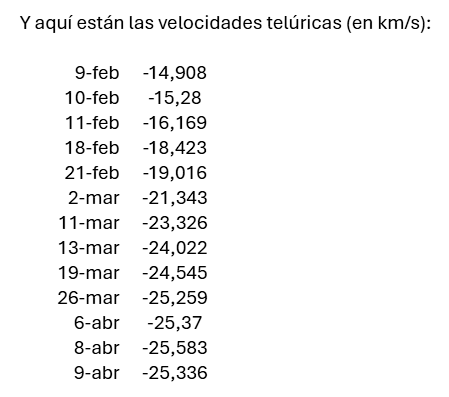

## LÍNEAS IDENTIFICADAS Th-Ar BENJAMIN MARZO 12
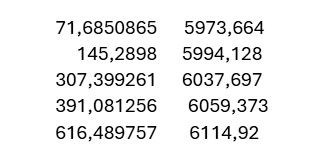

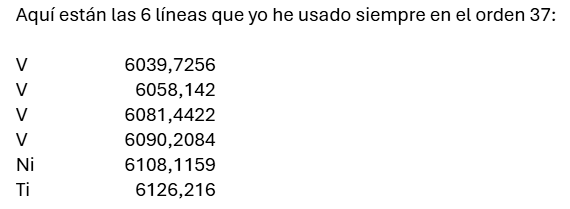

## DATOS MARZO 12

   pixel  intensidad
0      0           0
1      1           0
2      2           0
3      3           0
4      4          67
(900, 2)


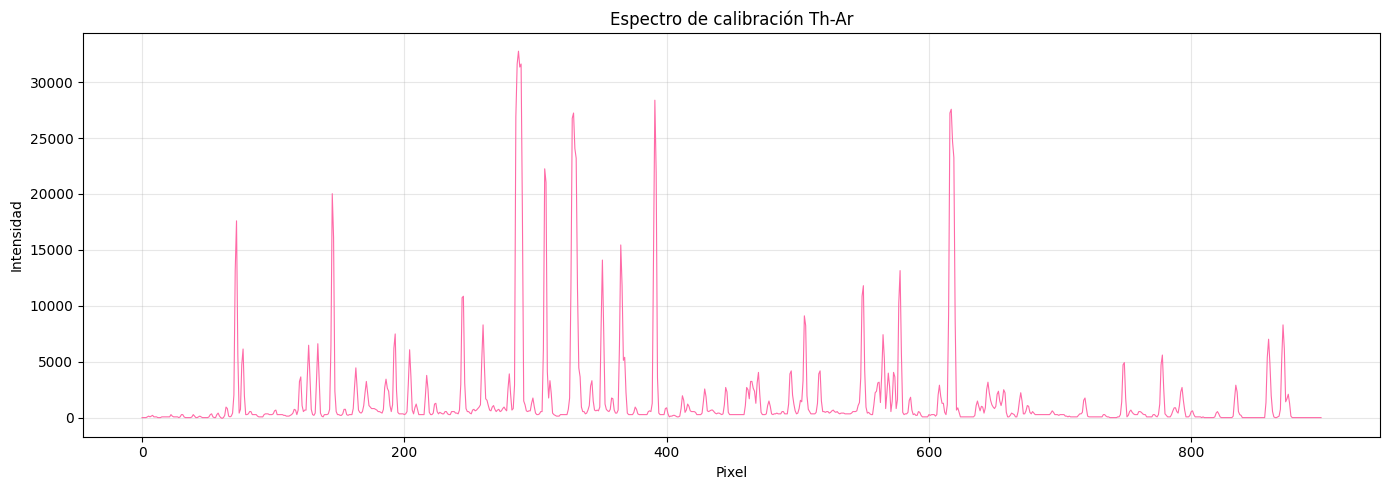

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

archivo_thar = "thor_marzo12.dat"

df_thar = pd.read_csv(
    archivo_thar,
    sep=r"\s+",
    header=None,
    names=["pixel", "intensidad"],
    engine="python"
)

print(df_thar.head())
print(df_thar.shape)

plt.figure(figsize=(14,5))
plt.plot(df_thar["pixel"], df_thar["intensidad"], linewidth=0.8, color="#ff6aa7")
plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title("Espectro de calibración Th-Ar")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cantidad de picos encontrados: 34
Pixeles de los picos: [ 72  77 121 127 134 145 163 193 204 217 245 260 280 287 307 329 351 365
 391 470 495 505 517 550 565 569 573 578 617 645 749 778 859 870]


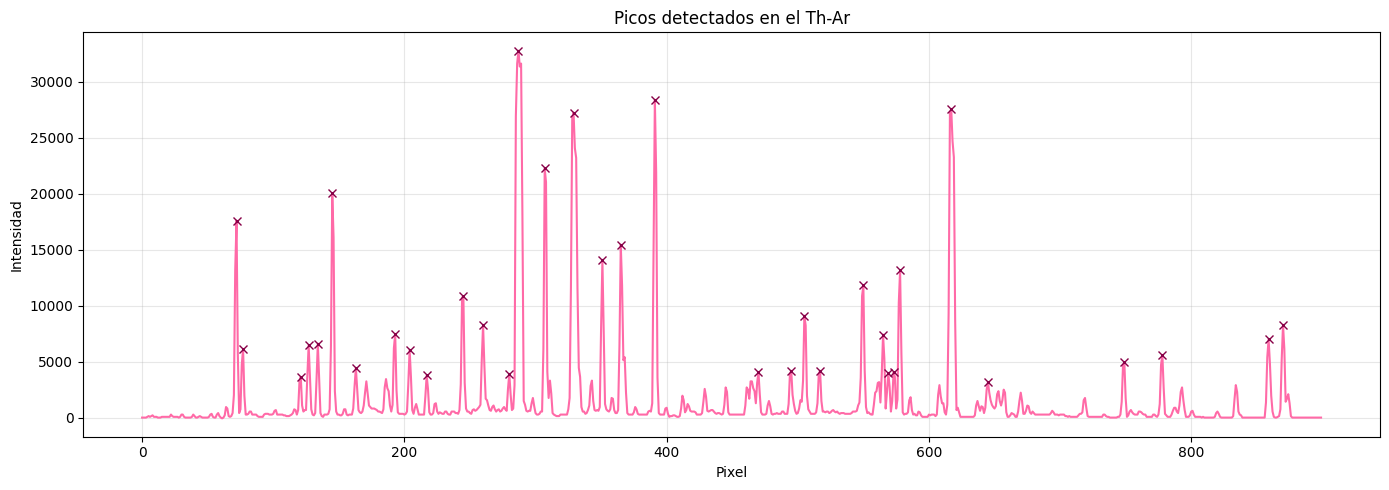

In [54]:
y = df_thar["intensidad"].values

peaks, properties = find_peaks(
    y,
    prominence=3000,
    distance=4
)

print("Cantidad de picos encontrados:", len(peaks))
print("Pixeles de los picos:", peaks)

plt.figure(figsize=(14,5))
plt.plot(df_thar["pixel"], df_thar["intensidad"], color="#ff6aa7")
plt.plot(df_thar.iloc[peaks]["pixel"], df_thar.iloc[peaks]["intensidad"], "x", color="#870047")
plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title("Picos detectados en el Th-Ar")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
tabla_picos = thar.iloc[peaks][["pixel", "intensidad"]].copy()
tabla_picos = tabla_picos.reset_index(drop=True)
print(tabla_picos)

    pixel  intensidad
0      73    3178.243
1      78    3194.228
2     122    3281.702
3     128    3292.521
4     135    3307.228
5     146    3334.604
6     164    3385.532
7     194    3449.645
8     205    3471.959
9     218    3495.700
10    246    3548.514
11    261    3564.333
12    281    3598.120
13    288    3605.879
14    308    3638.644
15    330    3666.981
16    352    3687.984
17    366    3703.230
18    392    3734.597
19    471    3856.354
20    496    3903.102
21    506    3918.070
22    518    3933.661
23    551    3973.196
24    566    3997.865
25    570    4001.893
26    574    4008.210
27    579    4013.870
28    618    4072.400
29    646    4110.826
30    750    4283.518
31    779    4333.560
32    860    4461.527
33    871    4482.169


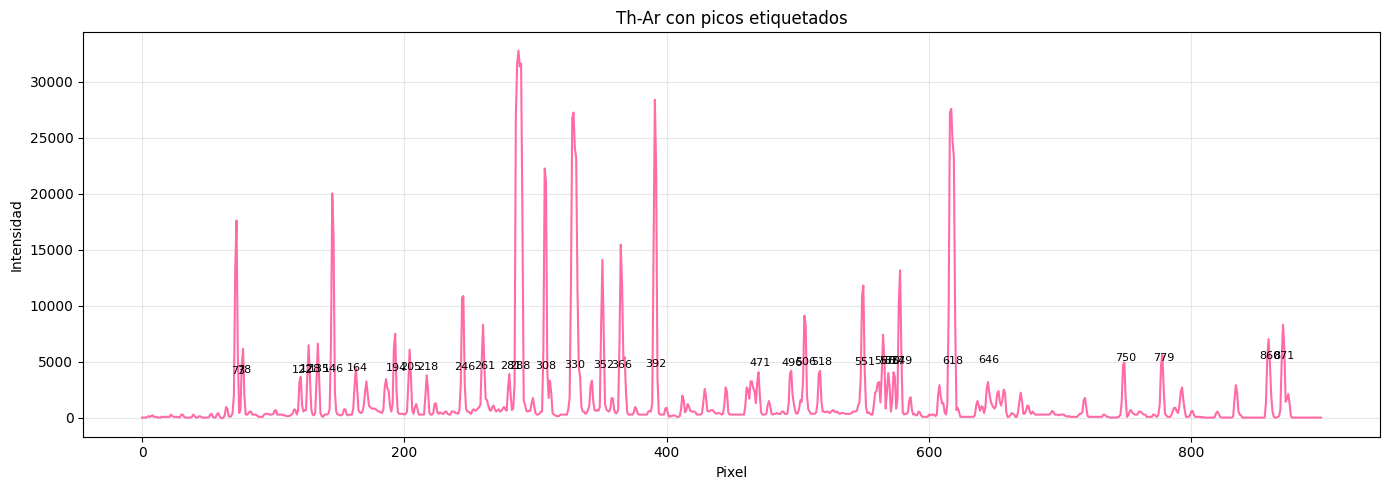

In [56]:
plt.figure(figsize=(14,5))
plt.plot(df_thar["pixel"], df_thar["intensidad"], color="#ff6aa7")

for _, fila in tabla_picos.iterrows():
    plt.annotate(
        str(int(fila["pixel"])),
        (fila["pixel"], fila["intensidad"]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title("Th-Ar con picos etiquetados")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Pico original en pixel: 72
Centro refinado: 71.77050027353904


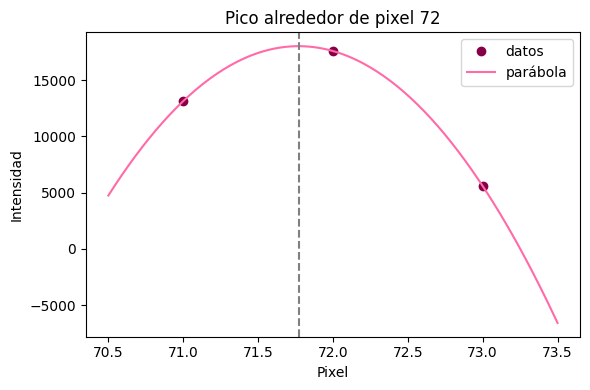

In [57]:
# escogemos un pico, por ejemplo el primero detectado
i = 0
p = peaks[i]

# tres puntos alrededor del máximo
x = np.array([p-1, p, p+1], dtype=float)
y = df_thar.loc[[p-1, p, p+1], "intensidad"].values.astype(float)

# ajuste parabólico y = ax^2 + bx + c
coef = np.polyfit(x, y, 2)
a, b, c = coef

# vértice de la parábola
x_centro = -b / (2*a)
y_centro = a*x_centro**2 + b*x_centro + c

print("Pico original en pixel:", p)
print("Centro refinado:", x_centro)

# dibujar
xx = np.linspace(p-1.5, p+1.5, 200)
yy = a*xx**2 + b*xx + c

plt.figure(figsize=(6,4))
plt.plot(x, y, "o", label="datos", color="#870047")
plt.plot(xx, yy, label="parábola", color="#ff6aa7")
plt.axvline(x_centro, linestyle="--", color="gray")
plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title(f"Pico alrededor de pixel {p}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
centros_refinados = []

for p in peaks:
    # evitar problemas en los bordes
    if p-1 >= 0 and p+1 < len(df_thar):
        x = np.array([p-1, p, p+1], dtype=float)
        y = df_thar.loc[[p-1, p, p+1], "intensidad"].values.astype(float)

        coef = np.polyfit(x, y, 2)
        a, b, c = coef

        # solo si realmente abre hacia abajo
        if a < 0:
            x_centro = -b / (2*a)
            y_centro = a*x_centro**2 + b*x_centro + c

            centros_refinados.append({
                "pixel_bruto": p,
                "pixel_centro": x_centro,
                "intensidad": y_centro
            })

import pandas as pd
tabla_centros = pd.DataFrame(centros_refinados)
print(tabla_centros)

    pixel_bruto  pixel_centro    intensidad
0            72     71.770500  18029.238109
1            77     76.753038   6305.650822
2           121    120.636210   3836.264498
3           127    126.982289   6472.898818
4           134    134.000000   6607.000000
5           145    145.276941  20695.205210
6           163    162.980742   4449.649964
7           193    192.702146   7764.099594
8           204    204.055576   6075.433643
9           217    217.108640   3793.305770
10          245    244.517115  11773.655236
11          260    259.965345   8296.089280
12          280    279.925686   3918.750434
13          287    286.947522  32769.529116
14          307    307.429936  23849.403887
15          329    328.629635  27486.718793
16          351    350.991814  14090.413398
17          365    365.212764  15725.912631
18          391    391.168968  28662.093454
19          470    469.825630   4089.072137
20          495    494.611203   4363.512355
21          505    505.368744   

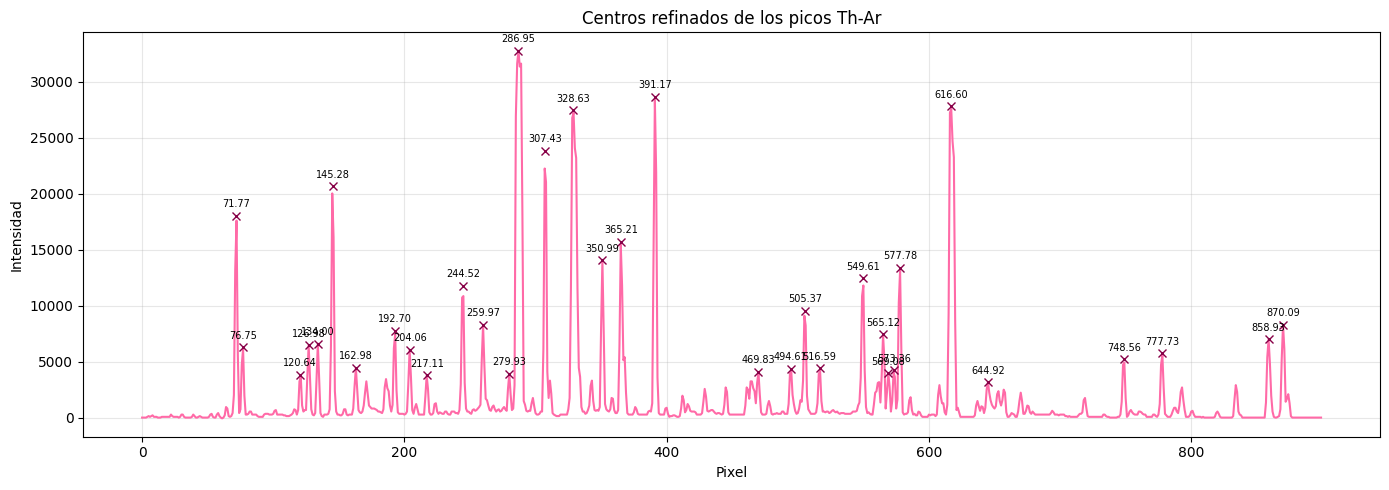

In [59]:
plt.figure(figsize=(14,5))
plt.plot(df_thar["pixel"], df_thar["intensidad"], color="#ff6aa7")

plt.plot(
    tabla_centros["pixel_centro"],
    tabla_centros["intensidad"],
    "x",
    color="#870047"
)

for _, fila in tabla_centros.iterrows():
    plt.annotate(
        f'{fila["pixel_centro"]:.2f}',
        (fila["pixel_centro"], fila["intensidad"]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=7
    )

plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title("Centros refinados de los picos Th-Ar")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
tabla_centros["lambda_aprox"] = 5949.44544 + 0.180579121 * tabla_centros["pixel_centro"]
print(tabla_centros)

    pixel_bruto  pixel_centro    intensidad  lambda_aprox
0            72     71.770500  18029.238109   5962.405694
1            77     76.753038   6305.650822   5963.305436
2           121    120.636210   3836.264498   5971.229821
3           127    126.982289   6472.898818   5972.375790
4           134    134.000000   6607.000000   5973.643042
5           145    145.276941  20695.205210   5975.679422
6           163    162.980742   4449.649964   5978.876359
7           193    192.702146   7764.099594   5984.243424
8           204    204.055576   6075.433643   5986.293617
9           217    217.108640   3793.305770   5988.650727
10          245    244.517115  11773.655236   5993.600126
11          260    259.965345   8296.089280   5996.389754
12          280    279.925686   3918.750434   5999.994174
13          287    286.947522  32769.529116   6001.262171
14          307    307.429936  23849.403887   6004.960868
15          329    328.629635  27486.718793   6008.789091
16          35

In [61]:
lineas = pd.read_csv(
    "thar_uves.dat",
    sep=r"\s+",
    header=None,
    engine="python"
)

print(lineas.head(10))
print(lineas.shape)

    0         1
0   1  2768.842
1   2  2795.531
2   3  2832.315
3   4  2837.295
4   5  2842.812
5   6  2851.259
6   7  2852.125
7   8  2870.406
8   9  2884.290
9  10  2885.049
(2455, 2)


In [62]:
print(lineas.columns)
print(lineas.iloc[:10, :])

Index([0, 1], dtype='int64')
    0         1
0   1  2768.842
1   2  2795.531
2   3  2832.315
3   4  2837.295
4   5  2842.812
5   6  2851.259
6   7  2852.125
7   8  2870.406
8   9  2884.290
9  10  2885.049


In [63]:
lineas_lam = lineas.iloc[:, 1].copy()
lineas_lam = pd.to_numeric(lineas_lam, errors="coerce")
lineas_lam = lineas_lam.dropna()
print(lineas_lam.head(20))

0     2768.842
1     2795.531
2     2832.315
3     2837.295
4     2842.812
5     2851.259
6     2852.125
7     2870.406
8     2884.290
9     2885.049
10    2887.818
11    2898.934
12    2899.720
13    2921.620
14    2925.051
15    2928.254
16    2942.860
17    2957.583
18    2957.916
19    2968.687
Name: 1, dtype: float64


In [64]:
lineas_region = lineas_lam[(lineas_lam > 5945) & (lineas_lam < 6110)]
lineas_region = lineas_region.sort_values().reset_index(drop=True)

print(lineas_region)

0     5948.799
1     5949.260
2     5955.561
3     5959.673
4     5962.056
        ...   
61    6103.560
62    6103.641
63    6104.568
64    6105.645
65    6107.533
Name: 1, Length: 66, dtype: float64


In [65]:
candidatas = []

for _, fila in tabla_centros.iterrows():
    lam = fila["lambda_aprox"]
    
    diferencias = abs(lineas_region - lam)
    idx_min = diferencias.idxmin()
    lam_mas_cercana = lineas_region.loc[idx_min]
    dif = abs(lam_mas_cercana - lam)
    
    candidatas.append({
        "pixel_centro": fila["pixel_centro"],
        "intensidad": fila["intensidad"],
        "lambda_aprox": lam,
        "lambda_candidata": lam_mas_cercana,
        "diferencia": dif
    })

tabla_candidatas = pd.DataFrame(candidatas)
print(tabla_candidatas)

    pixel_centro    intensidad  lambda_aprox  lambda_candidata  diferencia
0      71.770500  18029.238109   5962.405694          5962.056    0.349694
1      76.753038   6305.650822   5963.305436          5962.056    1.249436
2     120.636210   3836.264498   5971.229821          5971.590    0.360179
3     126.982289   6472.898818   5972.375790          5971.590    0.785790
4     134.000000   6607.000000   5973.643042          5973.664    0.020958
5     145.276941  20695.205210   5975.679422          5975.064    0.615422
6     162.980742   4449.649964   5978.876359          5981.900    3.023641
7     192.702146   7764.099594   5984.243424          5986.266    2.022576
8     204.055576   6075.433643   5986.293617          5986.266    0.027617
9     217.108640   3793.305770   5988.650727          5989.044    0.393273
10    244.517115  11773.655236   5993.600126          5994.128    0.527874
11    259.965345   8296.089280   5996.389754          5996.629    0.239246
12    279.925686   3918.7

In [67]:
buenas = tabla_candidatas[tabla_candidatas["diferencia"] < 0.3].copy()
print(buenas)

    pixel_centro    intensidad  lambda_aprox  lambda_candidata  diferencia
4     134.000000   6607.000000   5973.643042          5973.664    0.020958
8     204.055576   6075.433643   5986.293617          5986.266    0.027617
11    259.965345   8296.089280   5996.389754          5996.629    0.239246
13    286.947522  32769.529116   6001.262171          6001.203    0.059171
14    307.429936  23849.403887   6004.960868          6005.165    0.204132
17    365.212764  15725.912631   6015.395240          6015.422    0.026760
20    494.611203   4363.512355   6038.761896          6038.680    0.081896
22    516.591001   4428.160137   6042.730989          6042.589    0.141989
26    573.363498   4241.016557   6052.982917          6052.721    0.261917
29    644.916564   3173.631953   6065.903906          6065.779    0.124906
32    858.928609   7020.619900   6104.550013          6104.568    0.017987


In [68]:
seleccion = buenas.iloc[[0, 2, 4, 6, 8]].copy()
print(seleccion)

    pixel_centro    intensidad  lambda_aprox  lambda_candidata  diferencia
4     134.000000   6607.000000   5973.643042          5973.664    0.020958
11    259.965345   8296.089280   5996.389754          5996.629    0.239246
14    307.429936  23849.403887   6004.960868          6005.165    0.204132
20    494.611203   4363.512355   6038.761896          6038.680    0.081896
26    573.363498   4241.016557   6052.982917          6052.721    0.261917


Cantidad de líneas útiles en el atlas: 692
0     5002.097
1     5003.598
2     5004.127
3     5009.350
4     5015.889
5     5017.160
6     5017.254
7     5019.324
8     5019.806
9     5022.005
10    5028.655
11    5029.891
12    5039.230
13    5041.122
14    5044.719
15    5045.248
16    5047.043
17    5048.813
18    5048.936
19    5049.796
dtype: float64
Cantidad de picos detectados: 43

Centros refinados:
    pixel_bruto  pixel_centro    intensidad  prominencia
0            72     71.770500  18029.238109      17529.0
1            77     76.753038   6305.650822       5731.0
2           121    120.636210   3836.264498       3101.0
3           127    126.982289   6472.898818       6270.0
4           134    134.000000   6607.000000       6540.0
5           145    145.276941  20695.205210      19821.0
6           163    162.980742   4449.649964       4045.0
7           171    170.983979   3236.268352       2832.0
8           186    185.978401   3438.361783       2899.0
9           193    

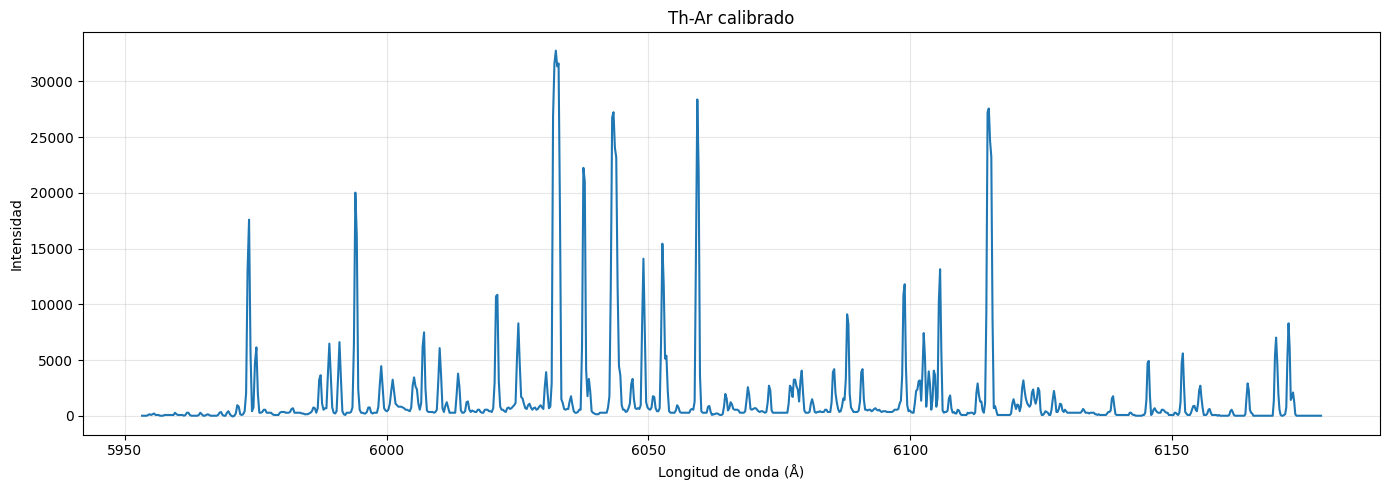

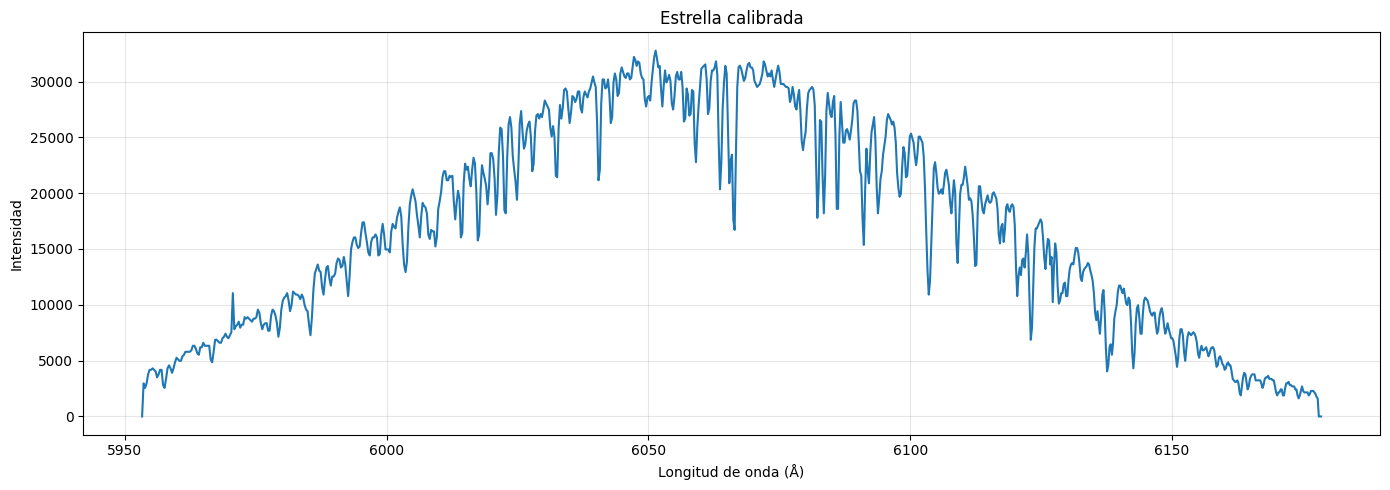

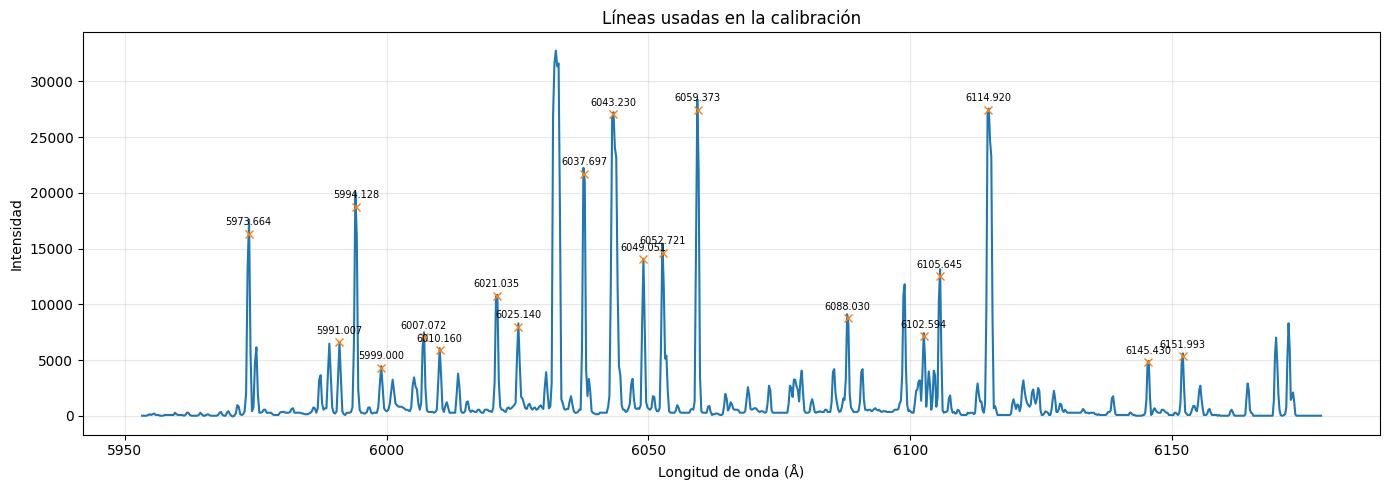


Archivos guardados:
 - lineas_calibracion_20_iniciales.csv
 - lineas_calibracion_finales.csv
 - thor_marzo12_calibrado.csv
 - estrella_marzo12_calibrada.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================================================
# 1) CARGAR ARCHIVOS
# =========================================================

star = pd.read_csv(
    "estrella_marzo12.dat",
    sep=r"\s+",
    header=None,
    names=["pixel", "intensidad"],
    engine="python"
)

thar = pd.read_csv(
    "thor_marzo12.dat",
    sep=r"\s+",
    header=None,
    names=["pixel", "intensidad"],
    engine="python"
)

# archivo de líneas del atlas ESO
# cambia el nombre si tu archivo se llama distinto
atlas_raw = pd.read_csv(
    "thar_uves.dat",
    sep=r"\s+",
    header=None,
    dtype=str,
    engine="python"
)

# =========================================================
# 2) EXTRAER TODAS LAS LONGITUDES DE ONDA NUMÉRICAS DEL ATLAS
#    (esto lo hago robusto por si el archivo tiene varias columnas)
# =========================================================

atlas_vals = pd.to_numeric(
    atlas_raw.stack().str.replace(",", ".", regex=False),
    errors="coerce"
).dropna()

# nos quedamos con valores razonables en Angstrom
atlas_lines = atlas_vals[(atlas_vals > 5000) & (atlas_vals < 7000)]
atlas_lines = atlas_lines.sort_values().drop_duplicates().reset_index(drop=True)

print("Cantidad de líneas útiles en el atlas:", len(atlas_lines))
print(atlas_lines.head(20))

# =========================================================
# 3) DETECTAR PICOS EN EL TH-AR
# =========================================================

y = thar["intensidad"].values

peaks, props = find_peaks(
    y,
    prominence=2000,   # si encuentra muy pocas, bájalo a 1500
    distance=4
)

print("Cantidad de picos detectados:", len(peaks))

# =========================================================
# 4) REFINAR EL CENTRO DE CADA PICO CON PARÁBOLA DE 3 PUNTOS
# =========================================================

centros = []

for p, prom in zip(peaks, props["prominences"]):
    if 1 <= p < len(thar) - 1:
        x = np.array([p - 1, p, p + 1], dtype=float)
        yy = thar.loc[[p - 1, p, p + 1], "intensidad"].values.astype(float)

        a, b, c = np.polyfit(x, yy, 2)

        if a != 0:
            x_centro = -b / (2 * a)
            y_centro = a * x_centro**2 + b * x_centro + c

            # chequeo simple para evitar centros absurdos
            if (p - 0.8) <= x_centro <= (p + 0.8):
                centros.append({
                    "pixel_bruto": p,
                    "pixel_centro": x_centro,
                    "intensidad": y_centro,
                    "prominencia": prom
                })

tabla_centros = pd.DataFrame(centros).sort_values("pixel_centro").reset_index(drop=True)

print("\nCentros refinados:")
print(tabla_centros.head(20))

# =========================================================
# 5) TUS 5 LÍNEAS MANUALES = SEMILLA
# =========================================================

seed = pd.DataFrame({
    "pixel": [
        71.6850865,
        145.2898,
        307.399261,
        391.081256,
        616.489757
    ],
    "lambda": [
        5973.664,
        5994.128,
        6037.697,
        6059.373,
        6114.92
    ]
})

# ajuste inicial cuadrático con tus 5 líneas
coef_seed = np.polyfit(seed["pixel"], seed["lambda"], 2)

print("\nCoeficientes semilla:")
print(coef_seed)

# =========================================================
# 6) USAR ESA SEMILLA PARA ESTIMAR LA LAMBDA DE TODOS LOS PICOS
# =========================================================

tabla_centros["lambda_seed"] = np.polyval(coef_seed, tabla_centros["pixel_centro"])

lam_min = tabla_centros["lambda_seed"].min() - 1.0
lam_max = tabla_centros["lambda_seed"].max() + 1.0

atlas_region = atlas_lines[(atlas_lines >= lam_min) & (atlas_lines <= lam_max)].reset_index(drop=True)

print("\nRango aproximado del orden:")
print(lam_min, lam_max)
print("Cantidad de líneas del atlas en esa región:", len(atlas_region))

# =========================================================
# 7) PARA CADA PICO, BUSCAR LA LÍNEA DEL ATLAS MÁS CERCANA
# =========================================================

candidatas = []

atlas_region_values = atlas_region.values

for _, fila in tabla_centros.iterrows():
    lam_est = fila["lambda_seed"]

    idx = np.argmin(np.abs(atlas_region_values - lam_est))
    lam_atlas = atlas_region_values[idx]
    diff = lam_atlas - lam_est

    candidatas.append({
        "pixel_centro": fila["pixel_centro"],
        "intensidad": fila["intensidad"],
        "prominencia": fila["prominencia"],
        "lambda_seed": lam_est,
        "lambda_atlas": lam_atlas,
        "diff_seed": diff,
        "absdiff": abs(diff)
    })

candidatas = pd.DataFrame(candidatas)

# nos quedamos solo con coincidencias razonables
# si salen muy pocas, cambia 0.20 por 0.25
candidatas = candidatas[candidatas["absdiff"] < 0.20].copy()

# eliminar líneas duplicadas del atlas
candidatas = candidatas.sort_values(
    ["lambda_atlas", "absdiff", "prominencia"],
    ascending=[True, True, False]
).drop_duplicates(subset="lambda_atlas", keep="first")

# =========================================================
# 8) ESCOGER ~20 LÍNEAS BUENAS
#    criterio:
#    - que sean fuertes
#    - que no queden demasiado pegadas
# =========================================================

seleccion = []

for _, fila in candidatas.sort_values(
    ["prominencia", "absdiff"],
    ascending=[False, True]
).iterrows():
    
    # evitar escoger líneas demasiado pegadas entre sí
    if all(abs(fila["pixel_centro"] - s["pixel_centro"]) > 8 for s in seleccion):
        seleccion.append(fila)

    if len(seleccion) == 20:
        break

cal20 = pd.DataFrame(seleccion).sort_values("pixel_centro").reset_index(drop=True)

print("\nLíneas automáticas seleccionadas:")
print(cal20[["pixel_centro", "lambda_atlas", "absdiff", "prominencia"]])

print("\nCantidad final de líneas usadas:", len(cal20))

# guardar por si quieres revisarlas a mano
cal20.to_csv("lineas_calibracion_20_iniciales.csv", index=False)

# =========================================================
# 9) AJUSTAR CON ESAS ~20 LÍNEAS
#    probamos grado 2 y grado 3
# =========================================================

coef2 = np.polyfit(cal20["pixel_centro"], cal20["lambda_atlas"], 2)
coef3 = np.polyfit(cal20["pixel_centro"], cal20["lambda_atlas"], 3)

cal20["fit2"] = np.polyval(coef2, cal20["pixel_centro"])
cal20["fit3"] = np.polyval(coef3, cal20["pixel_centro"])

cal20["res2"] = cal20["fit2"] - cal20["lambda_atlas"]
cal20["res3"] = cal20["fit3"] - cal20["lambda_atlas"]

rms2 = np.sqrt(np.mean(cal20["res2"]**2))
rms3 = np.sqrt(np.mean(cal20["res3"]**2))

print("\nRMS grado 2 =", rms2)
print("RMS grado 3 =", rms3)

# elegir el mejor
if rms3 < 0.8 * rms2:
    coef_final = coef3
    grado_final = 3
else:
    coef_final = coef2
    grado_final = 2

print("\nGrado elegido:", grado_final)
print("Coeficientes finales:", coef_final)

# =========================================================
# 10) RECHAZAR OUTLIERS Y REAJUSTAR
# =========================================================

if grado_final == 2:
    cal20["fit_final"] = np.polyval(coef_final, cal20["pixel_centro"])
else:
    cal20["fit_final"] = np.polyval(coef_final, cal20["pixel_centro"])

cal20["res_final"] = cal20["fit_final"] - cal20["lambda_atlas"]

# si quieres ser más laxa, cambia 0.08 por 0.10
buenas = cal20[np.abs(cal20["res_final"]) < 0.08].copy()

print("\nLíneas buenas después de quitar outliers:")
print(buenas[["pixel_centro", "lambda_atlas", "res_final"]])
print("Cantidad:", len(buenas))

# reajuste final con las buenas
coef2_b = np.polyfit(buenas["pixel_centro"], buenas["lambda_atlas"], 2)
coef3_b = np.polyfit(buenas["pixel_centro"], buenas["lambda_atlas"], 3)

buenas["fit2_b"] = np.polyval(coef2_b, buenas["pixel_centro"])
buenas["fit3_b"] = np.polyval(coef3_b, buenas["pixel_centro"])

rms2_b = np.sqrt(np.mean((buenas["fit2_b"] - buenas["lambda_atlas"])**2))
rms3_b = np.sqrt(np.mean((buenas["fit3_b"] - buenas["lambda_atlas"])**2))

print("\nRMS final grado 2 =", rms2_b)
print("RMS final grado 3 =", rms3_b)

if rms3_b < 0.8 * rms2_b:
    coef = coef3_b
    grado = 3
else:
    coef = coef2_b
    grado = 2

print("\nPOLINOMIO FINAL")
print("Grado =", grado)
print("Coef =", coef)

# =========================================================
# 11) APLICAR CALIBRACIÓN FINAL
# =========================================================

thar["lambda_cal"] = np.polyval(coef, thar["pixel"])
star["lambda_cal"] = np.polyval(coef, star["pixel"])

# =========================================================
# 12) REVISAR RESIDUALES FINALES
# =========================================================

buenas["lambda_fit"] = np.polyval(coef, buenas["pixel_centro"])
buenas["residual_final"] = buenas["lambda_fit"] - buenas["lambda_atlas"]

rms_final = np.sqrt(np.mean(buenas["residual_final"]**2))

print("\nRMS FINAL TOTAL =", rms_final)
print("\nTabla final de líneas:")
print(buenas[["pixel_centro", "lambda_atlas", "lambda_fit", "residual_final"]])

buenas.to_csv("lineas_calibracion_finales.csv", index=False)

# =========================================================
# 13) GRAFICAR TH-AR CALIBRADO
# =========================================================

plt.figure(figsize=(14,5))
plt.plot(thar["lambda_cal"], thar["intensidad"])
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Intensidad")
plt.title("Th-Ar calibrado")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 14) GRAFICAR ESTRELLA CALIBRADA
# =========================================================

plt.figure(figsize=(14,5))
plt.plot(star["lambda_cal"], star["intensidad"])
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Intensidad")
plt.title("Estrella calibrada")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 15) GRAFICAR LOS PUNTOS DE CALIBRACIÓN SOBRE EL TH-AR
# =========================================================

plt.figure(figsize=(14,5))
plt.plot(thar["lambda_cal"], thar["intensidad"])

plt.plot(
    buenas["lambda_atlas"],
    np.interp(buenas["lambda_atlas"], thar["lambda_cal"], thar["intensidad"]),
    "x"
)

for _, fila in buenas.iterrows():
    ytxt = np.interp(fila["lambda_atlas"], thar["lambda_cal"], thar["intensidad"])
    plt.annotate(
        f'{fila["lambda_atlas"]:.3f}',
        (fila["lambda_atlas"], ytxt),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=7
    )

plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Intensidad")
plt.title("Líneas usadas en la calibración")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 16) GUARDAR ESPECTROS CALIBRADOS
# =========================================================

thar.to_csv("thor_marzo12_calibrado.csv", index=False)
star.to_csv("estrella_marzo12_calibrada.csv", index=False)

print("\nArchivos guardados:")
print(" - lineas_calibracion_20_iniciales.csv")
print(" - lineas_calibracion_finales.csv")
print(" - thor_marzo12_calibrado.csv")
print(" - estrella_marzo12_calibrada.csv")

Cantidad de picos encontrados: 34
Pixeles de los picos: [ 72  77 121 127 134 145 163 193 204 217 245 260 280 287 307 329 351 365
 391 470 495 505 517 550 565 569 573 578 617 645 749 778 859 870]


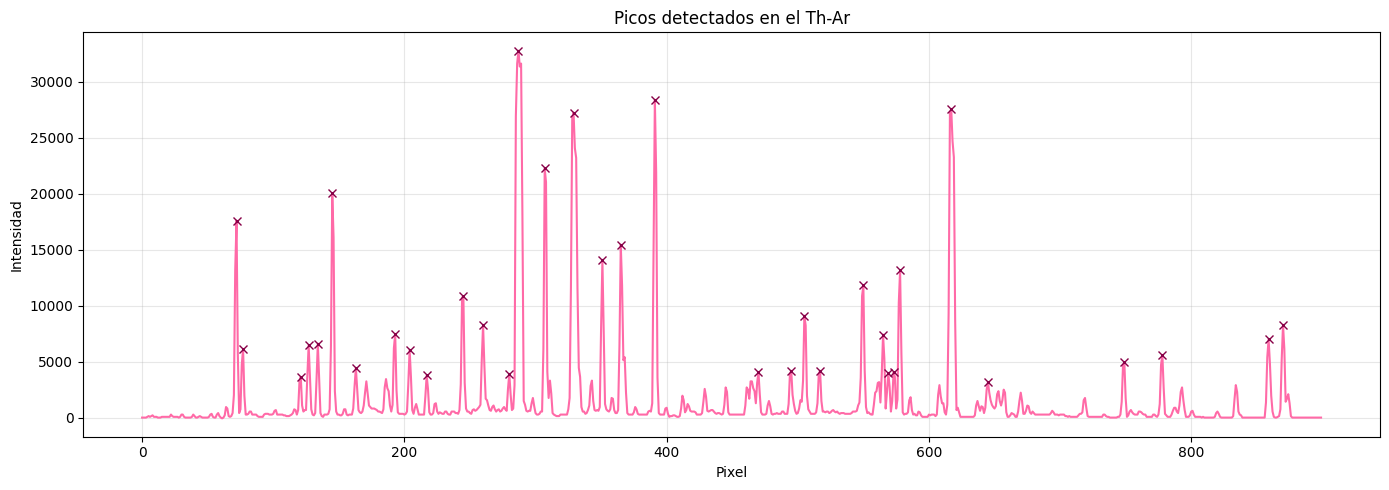


Tabla de centros refinados:
    pixel_bruto  pixel_centro    intensidad  prominencia
0            72     71.770500  18029.238109      17529.0
1            77     76.753038   6305.650822       5731.0
2           121    120.636210   3836.264498       3101.0
3           127    126.982289   6472.898818       6270.0
4           134    134.000000   6607.000000       6540.0
5           145    145.276941  20695.205210      19821.0
6           163    162.980742   4449.649964       4045.0
7           193    192.702146   7764.099594       7214.0
8           204    204.055576   6075.433643       5798.0
9           217    217.108640   3793.305770       3506.0
10          245    244.517115  11773.655236      10517.0
11          260    259.965345   8296.089280       7753.0
12          280    279.925686   3918.750434       3236.0
13          287    286.947522  32769.529116      32766.0
14          307    307.429936  23849.403887      21979.0
15          329    328.629635  27486.718793      26968.0
16

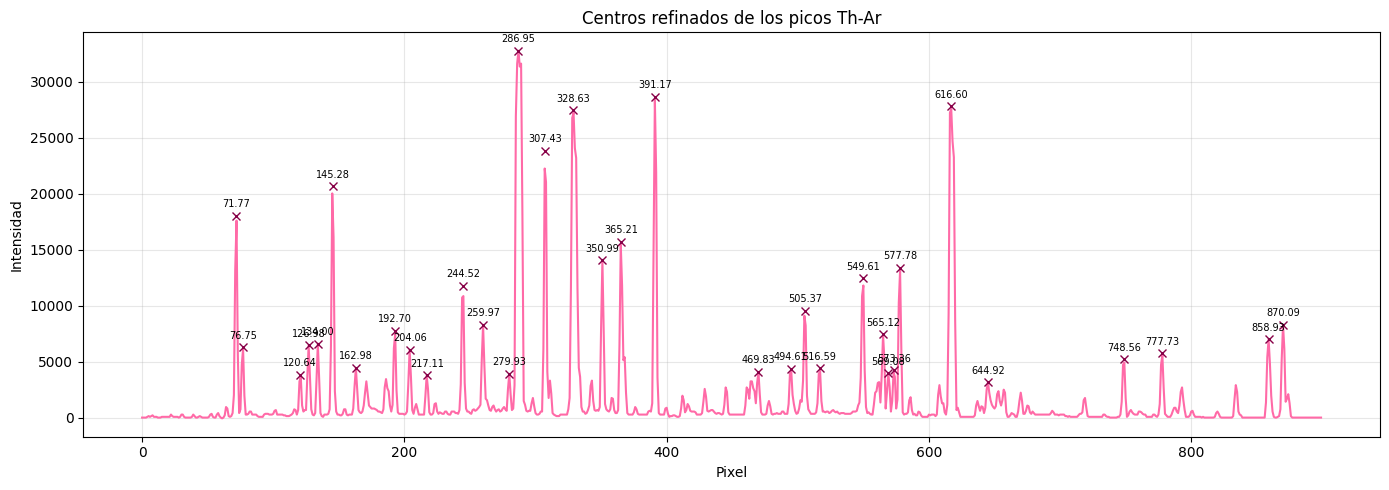


Líneas manuales:
   pixel_manual  lambda_manual
0     71.685086       5973.664
1    145.289800       5994.128
2    307.399261       6037.697
3    391.081256       6059.373
4    616.489757       6114.920

Emparejamiento manual vs centro refinado:
   pixel_manual  pixel_refinado  delta_pixel    intensidad  prominencia  \
0     71.685086       71.770500     0.085414  18029.238109      17529.0   
1    145.289800      145.276941    -0.012859  20695.205210      19821.0   
2    307.399261      307.429936     0.030675  23849.403887      21979.0   
3    391.081256      391.168968     0.087712  28662.093454      28249.0   
4    616.489757      616.604141     0.114384  27827.547744      27507.0   

   lambda_manual  
0       5973.664  
1       5994.128  
2       6037.697  
3       6059.373  
4       6114.920  

Coeficientes semilla: [-4.02792420e-05  2.86982184e-01  5.95327907e+03]

Cantidad total de líneas útiles en el atlas: 692

Rango aproximado del orden:
lambda min = 5972.668449097503
lambd

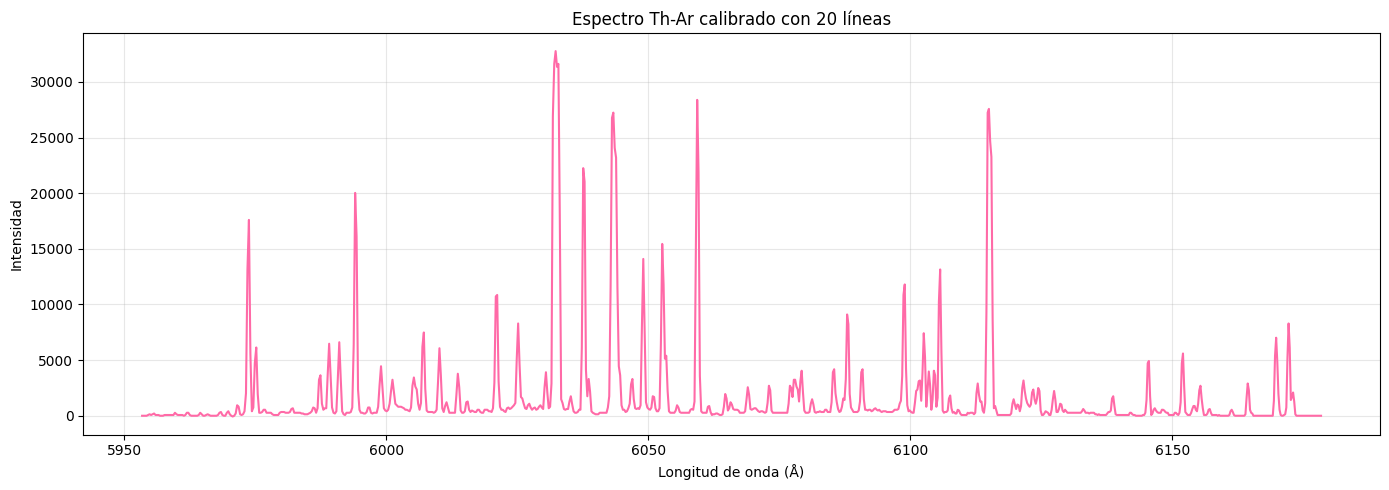

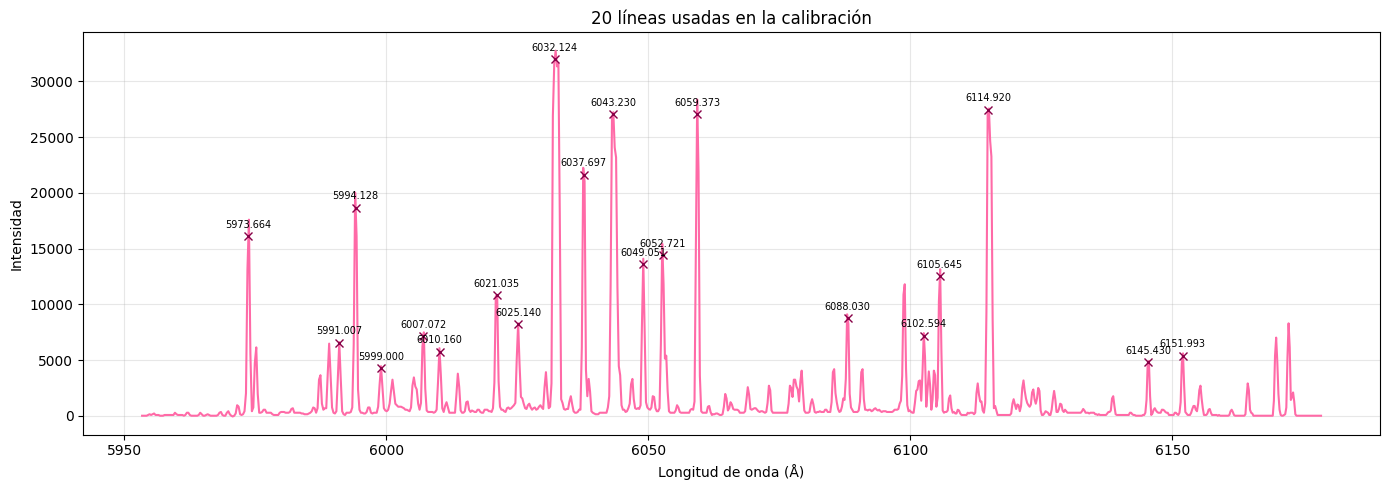

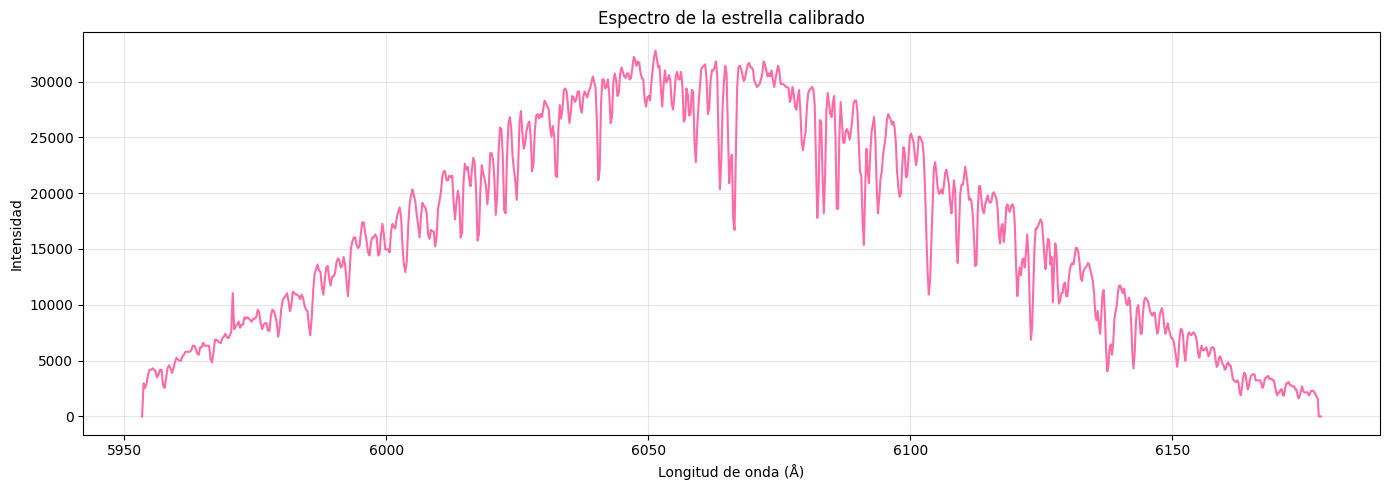


Archivos guardados:
- tabla_picos_brutos.csv
- tabla_centros_refinados.csv
- lineas_manual_semilla.csv
- lineas_calibracion_20.csv
- thor_marzo12_calibrado_20lineas.csv
- estrella_marzo12_calibrada_20lineas.csv


   pixel  intensidad
0      0           0
1      1        2964
2      2        2560
3      3        2964
4      4        3773
(900, 2)


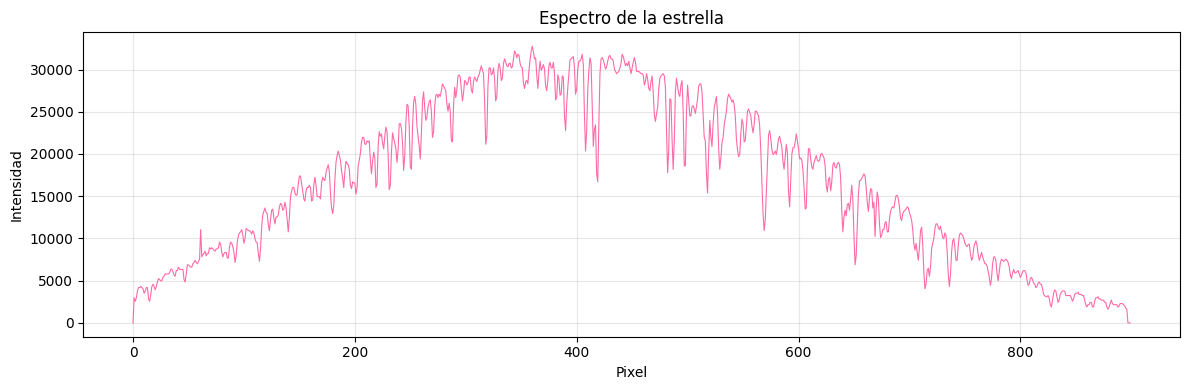

In [66]:
archivo = "estrella_marzo12.dat"  

df = pd.read_csv(
    archivo,
    sep=r"\s+",
    header=None,
    names=["pixel", "intensidad"],
    engine="python"
)

print(df.head())
print(df.shape)

plt.figure(figsize=(12,4))
plt.plot(df["pixel"], df["intensidad"], linewidth=0.8, color="#ff6aa7")
plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title("Espectro de la estrella")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cantidad inicial de picos encontrados: 34
Cantidad de picos después de quitar dobles máximos: 33
Pixeles de los picos válidos: [ 72  77 121 127 134 145 163 193 204 217 245 260 280 307 329 351 365 391
 470 495 505 517 550 565 569 573 578 617 645 749 778 859 870]


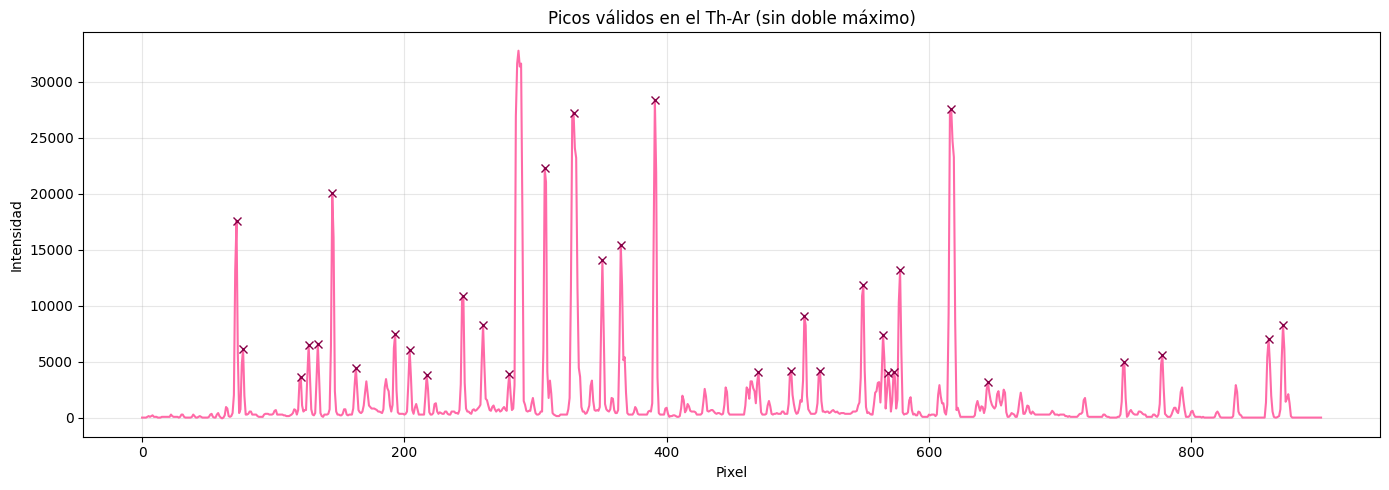


Tabla de centros refinados:
    pixel_bruto  pixel_centro    intensidad  prominencia
0            72     71.770500  18029.238109      17529.0
1            77     76.753038   6305.650822       5731.0
2           121    120.636210   3836.264498       3101.0
3           127    126.982289   6472.898818       6270.0
4           134    134.000000   6607.000000       6540.0
5           145    145.276941  20695.205210      19821.0
6           163    162.980742   4449.649964       4045.0
7           193    192.702146   7764.099594       7214.0
8           204    204.055576   6075.433643       5798.0
9           217    217.108640   3793.305770       3506.0
10          245    244.517115  11773.655236      10517.0
11          260    259.965345   8296.089280       7753.0
12          280    279.925686   3918.750434       3236.0
13          307    307.429936  23849.403887      21979.0
14          329    328.629635  27486.718793      26968.0
15          351    350.991814  14090.413398      13686.0
16

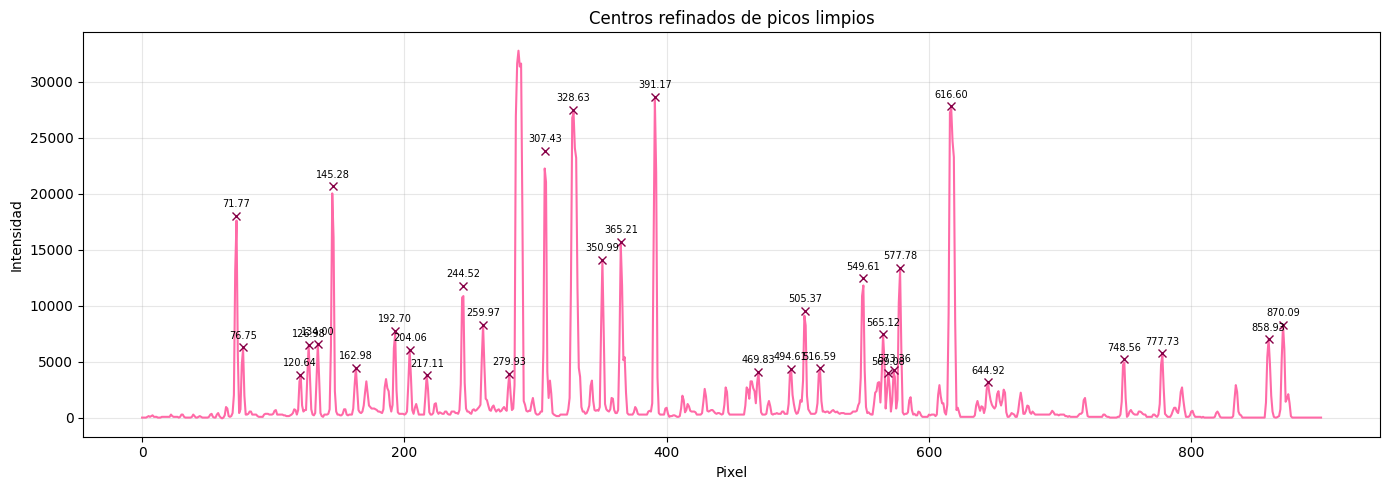


Líneas manuales:
   pixel_manual  lambda_manual
0     71.685086       5973.664
1    145.289800       5994.128
2    307.399261       6037.697
3    391.081256       6059.373
4    616.489757       6114.920

Emparejamiento manual vs centro refinado:
   pixel_manual  pixel_refinado  delta_pixel    intensidad  prominencia  \
0     71.685086       71.770500     0.085414  18029.238109      17529.0   
1    145.289800      145.276941    -0.012859  20695.205210      19821.0   
2    307.399261      307.429936     0.030675  23849.403887      21979.0   
3    391.081256      391.168968     0.087712  28662.093454      28249.0   
4    616.489757      616.604141     0.114384  27827.547744      27507.0   

   lambda_manual  
0       5973.664  
1       5994.128  
2       6037.697  
3       6059.373  
4       6114.920  

Coeficientes semilla: [-4.02792420e-05  2.86982184e-01  5.95327907e+03]

Cantidad total de líneas útiles en el atlas: 692

Rango aproximado del orden:
lambda min = 5972.668449097503
lambd

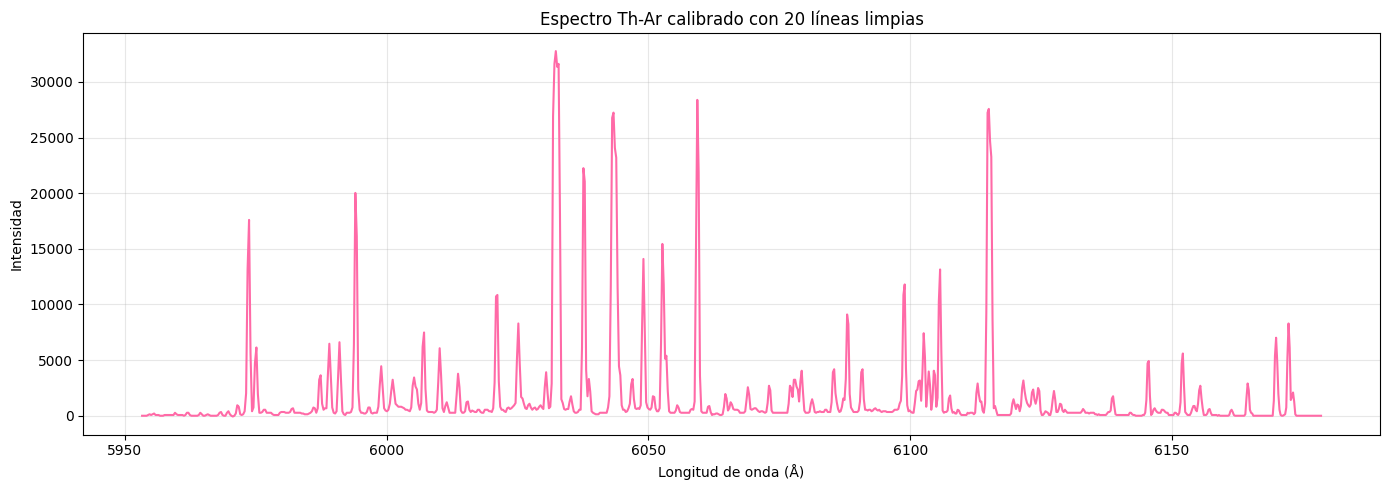

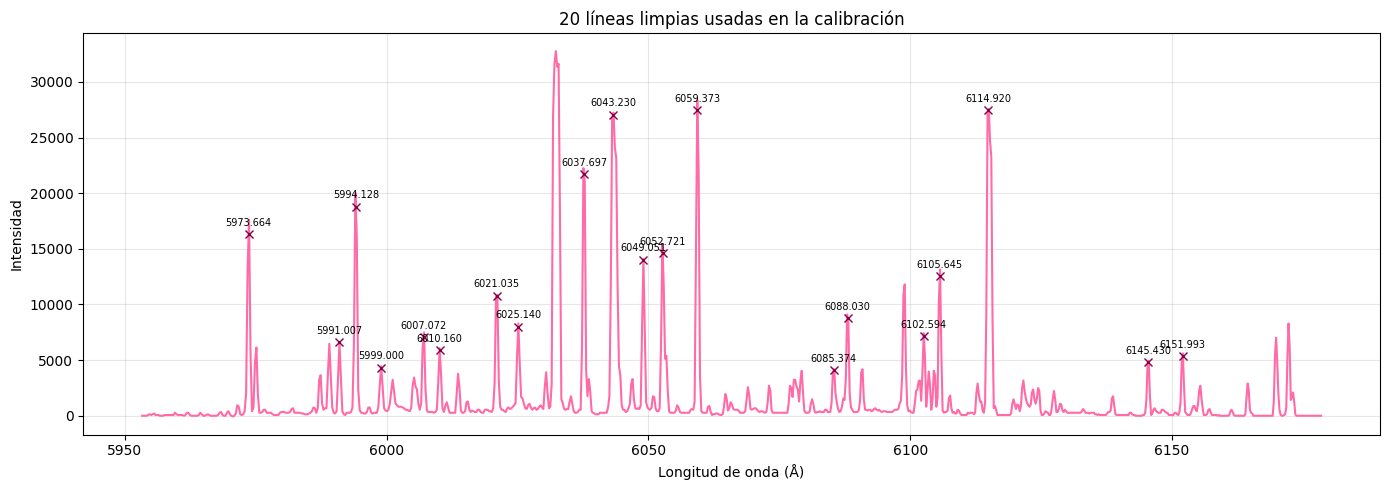

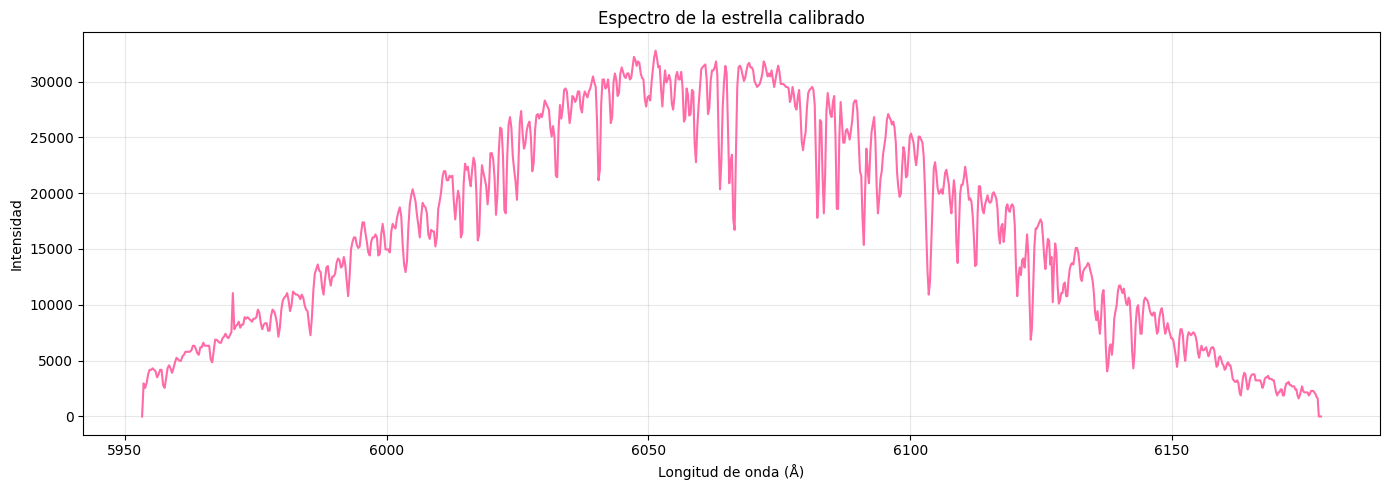


Archivos guardados:
- tabla_picos_brutos.csv
- tabla_centros_refinados_sin_dobles.csv
- lineas_manual_semilla.csv
- lineas_calibracion_20_sin_dobles.csv
- thor_marzo12_calibrado_20lineas_sin_dobles.csv
- estrella_marzo12_calibrada_20lineas_sin_dobles.csv


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================================================
# 0) CARGAR ARCHIVOS
# =========================================================
df_thar = pd.read_csv(
    "thor_marzo12.dat",
    sep=r"\s+",
    header=None,
    names=["pixel", "intensidad"],
    engine="python"
)

df_star = pd.read_csv(
    "estrella_marzo12.dat",
    sep=r"\s+",
    header=None,
    names=["pixel", "intensidad"],
    engine="python"
)

atlas_raw = pd.read_csv(
    "thar_uves.dat",
    sep=r"\s+",
    header=None,
    dtype=str,
    engine="python"
)

# =========================================================
# 1) FUNCIÓN PARA RECHAZAR PICOS CON DOBLE MÁXIMO
# =========================================================
def pico_unico(y, p, ventana=3):
    """
    Devuelve True si el pico en p parece tener máximo único
    dentro de una ventana local.

    Rechaza:
    - mesetas: y[p] <= vecino
    - doble máximo: más de un máximo local en la ventana
    """
    n = len(y)

    if p - ventana < 0 or p + ventana >= n:
        return False

    # condición mínima: el punto central debe ser estrictamente mayor
    # que sus vecinos inmediatos
    if not (y[p] > y[p-1] and y[p] > y[p+1]):
        return False

    # contar máximos locales estrictos en la ventana
    maximos_locales = 0
    for i in range(p - ventana + 1, p + ventana):
        if y[i] > y[i-1] and y[i] > y[i+1]:
            maximos_locales += 1

    # solo aceptamos un máximo local en toda la ventana
    return maximos_locales == 1

# =========================================================
# 2) DETECTAR PICOS BRUTOS EN EL TH-AR
# =========================================================
y = df_thar["intensidad"].values

peaks, properties = find_peaks(
    y,
    prominence=3000,   # si salen muy pocas líneas, prueba 2500 o 2000
    distance=4
)

print("Cantidad inicial de picos encontrados:", len(peaks))

# =========================================================
# 3) FILTRAR SOLO PICOS DE MÁXIMO ÚNICO
# =========================================================
peaks_filtrados = []
prom_filtradas = []

for p, prom in zip(peaks, properties["prominences"]):
    if pico_unico(y, p, ventana=3):
        peaks_filtrados.append(p)
        prom_filtradas.append(prom)

peaks = np.array(peaks_filtrados)
prom_filtradas = np.array(prom_filtradas)

print("Cantidad de picos después de quitar dobles máximos:", len(peaks))
print("Pixeles de los picos válidos:", peaks)

plt.figure(figsize=(14, 5))
plt.plot(df_thar["pixel"], df_thar["intensidad"], color="#ff6aa7")
plt.plot(df_thar.iloc[peaks]["pixel"], df_thar.iloc[peaks]["intensidad"], "x", color="#870047")
plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title("Picos válidos en el Th-Ar (sin doble máximo)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tabla_picos = df_thar.iloc[peaks][["pixel", "intensidad"]].copy().reset_index(drop=True)

# =========================================================
# 4) REFINAR CENTROS CON TU MÉTODO ORIGINAL
#    (PARÁBOLA DE 3 PUNTOS)
# =========================================================
centros_refinados = []

for p, prom in zip(peaks, prom_filtradas):
    if p - 1 >= 0 and p + 1 < len(df_thar):
        x = np.array([p - 1, p, p + 1], dtype=float)
        y_local = df_thar.loc[[p - 1, p, p + 1], "intensidad"].values.astype(float)

        coef = np.polyfit(x, y_local, 2)
        a, b, c = coef

        if a < 0:
            x_centro = -b / (2 * a)
            y_centro = a * x_centro**2 + b * x_centro + c

            # filtro extra: el centro refinado debe quedar cerca del pico bruto
            if (p - 0.8) <= x_centro <= (p + 0.8):
                centros_refinados.append({
                    "pixel_bruto": p,
                    "pixel_centro": x_centro,
                    "intensidad": y_centro,
                    "prominencia": prom
                })

tabla_centros = pd.DataFrame(centros_refinados).sort_values("pixel_centro").reset_index(drop=True)

print("\nTabla de centros refinados:")
print(tabla_centros)

plt.figure(figsize=(14, 5))
plt.plot(df_thar["pixel"], df_thar["intensidad"], color="#ff6aa7")
plt.plot(
    tabla_centros["pixel_centro"],
    tabla_centros["intensidad"],
    "x",
    color="#870047"
)

for _, fila in tabla_centros.iterrows():
    plt.annotate(
        f'{fila["pixel_centro"]:.2f}',
        (fila["pixel_centro"], fila["intensidad"]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=7
    )

plt.xlabel("Pixel")
plt.ylabel("Intensidad")
plt.title("Centros refinados de picos limpios")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 5) TUS 5 LÍNEAS MANUALES = SEMILLA
# =========================================================
lineas_manual = pd.DataFrame({
    "pixel_manual": [
        71.6850865,
        145.2898,
        307.399261,
        391.081256,
        616.489757
    ],
    "lambda_manual": [
        5973.664,
        5994.128,
        6037.697,
        6059.373,
        6114.92
    ]
})

print("\nLíneas manuales:")
print(lineas_manual)

# =========================================================
# 6) ASOCIAR CADA LÍNEA MANUAL CON EL CENTRO REFINADO MÁS CERCANO
# =========================================================
asociaciones = []

for _, fila in lineas_manual.iterrows():
    pixel_m = fila["pixel_manual"]
    lambda_m = fila["lambda_manual"]

    diferencias = np.abs(tabla_centros["pixel_centro"] - pixel_m)
    idx = diferencias.idxmin()

    pixel_refinado = tabla_centros.loc[idx, "pixel_centro"]
    intensidad = tabla_centros.loc[idx, "intensidad"]
    prominencia = tabla_centros.loc[idx, "prominencia"]

    asociaciones.append({
        "pixel_manual": pixel_m,
        "pixel_refinado": pixel_refinado,
        "delta_pixel": pixel_refinado - pixel_m,
        "intensidad": intensidad,
        "prominencia": prominencia,
        "lambda_manual": lambda_m
    })

tabla_match = pd.DataFrame(asociaciones)

print("\nEmparejamiento manual vs centro refinado:")
print(tabla_match)

# =========================================================
# 7) CALIBRACIÓN SEMILLA CON TUS 5 LÍNEAS
# =========================================================
x_seed = tabla_match["pixel_refinado"].values
y_seed = tabla_match["lambda_manual"].values

coef_seed = np.polyfit(x_seed, y_seed, 2)

print("\nCoeficientes semilla:", coef_seed)

# =========================================================
# 8) EXTRAER LONGITUDES DE ONDA DEL ATLAS
# =========================================================
atlas_vals = pd.to_numeric(
    atlas_raw.stack().str.replace(",", ".", regex=False),
    errors="coerce"
).dropna()

atlas_lines = atlas_vals[(atlas_vals > 5000) & (atlas_vals < 7000)]
atlas_lines = atlas_lines.sort_values().drop_duplicates().reset_index(drop=True)

print("\nCantidad total de líneas útiles en el atlas:", len(atlas_lines))

# =========================================================
# 9) USAR LA SEMILLA PARA ESTIMAR LAMBDA DE TODOS LOS PICOS
# =========================================================
tabla_centros["lambda_seed"] = np.polyval(coef_seed, tabla_centros["pixel_centro"])

lam_min = tabla_centros["lambda_seed"].min() - 1.0
lam_max = tabla_centros["lambda_seed"].max() + 1.0

atlas_region = atlas_lines[(atlas_lines >= lam_min) & (atlas_lines <= lam_max)].reset_index(drop=True)

print("\nRango aproximado del orden:")
print("lambda min =", lam_min)
print("lambda max =", lam_max)
print("Cantidad de líneas del atlas en esta región:", len(atlas_region))

# =========================================================
# 10) PARA CADA CENTRO, BUSCAR LA LÍNEA DEL ATLAS MÁS CERCANA
# =========================================================
candidatas = []

atlas_region_values = atlas_region.values

for _, fila in tabla_centros.iterrows():
    lam_est = fila["lambda_seed"]

    idx = np.argmin(np.abs(atlas_region_values - lam_est))
    lam_atlas = atlas_region_values[idx]
    diff = lam_atlas - lam_est

    candidatas.append({
        "pixel_bruto": fila["pixel_bruto"],
        "pixel_centro": fila["pixel_centro"],
        "intensidad": fila["intensidad"],
        "prominencia": fila["prominencia"],
        "lambda_seed": lam_est,
        "lambda_atlas": lam_atlas,
        "diff_seed": diff,
        "absdiff": abs(diff)
    })

candidatas = pd.DataFrame(candidatas)

# tolerancia de coincidencia con la semilla
candidatas = candidatas[candidatas["absdiff"] < 0.20].copy()

# quitar duplicados del atlas
candidatas = candidatas.sort_values(
    ["lambda_atlas", "absdiff", "prominencia"],
    ascending=[True, True, False]
).drop_duplicates(subset="lambda_atlas", keep="first")

print("\nCandidatas después del filtrado:")
print(candidatas[["pixel_centro", "lambda_seed", "lambda_atlas", "absdiff", "prominencia"]])

# =========================================================
# 11) ESCOGER EXACTAMENTE 20 LÍNEAS
#    SOLO DE PICOS LIMPIOS
# =========================================================
seleccion = []

for _, fila in candidatas.sort_values(
    ["prominencia", "absdiff"],
    ascending=[False, True]
).iterrows():

    if all(abs(fila["pixel_centro"] - s["pixel_centro"]) > 8 for s in seleccion):
        seleccion.append(fila)

    if len(seleccion) == 20:
        break

cal20 = pd.DataFrame(seleccion).sort_values("pixel_centro").reset_index(drop=True)

print("\n20 líneas seleccionadas para calibrar:")
print(cal20[["pixel_centro", "lambda_atlas", "absdiff", "prominencia"]])

print("\nCantidad final seleccionada:", len(cal20))

if len(cal20) < 20:
    raise ValueError(
        f"Solo se pudieron seleccionar {len(cal20)} líneas limpias. "
        f"Prueba bajar prominence a 2500 o 2000, o subir absdiff a 0.25."
    )

# =========================================================
# 12) AJUSTAR CALIBRACIÓN CON LAS 20 LÍNEAS
# =========================================================
coef2 = np.polyfit(cal20["pixel_centro"], cal20["lambda_atlas"], 2)
coef3 = np.polyfit(cal20["pixel_centro"], cal20["lambda_atlas"], 3)

cal20["fit2"] = np.polyval(coef2, cal20["pixel_centro"])
cal20["fit3"] = np.polyval(coef3, cal20["pixel_centro"])

cal20["res2"] = cal20["fit2"] - cal20["lambda_atlas"]
cal20["res3"] = cal20["fit3"] - cal20["lambda_atlas"]

rms2 = np.sqrt(np.mean(cal20["res2"]**2))
rms3 = np.sqrt(np.mean(cal20["res3"]**2))

print("\nRMS grado 2 =", rms2)
print("RMS grado 3 =", rms3)

if rms3 < rms2:
    coef_final = coef3
    grado_final = 3
    cal20["lambda_fit"] = cal20["fit3"]
    cal20["residual_final"] = cal20["res3"]
else:
    coef_final = coef2
    grado_final = 2
    cal20["lambda_fit"] = cal20["fit2"]
    cal20["residual_final"] = cal20["res2"]

print("\nGrado elegido:", grado_final)
print("Coeficientes finales:", coef_final)

print("\nTabla final de 20 líneas:")
print(cal20[["pixel_centro", "lambda_atlas", "lambda_fit", "residual_final"]])

rms_final = np.sqrt(np.mean(cal20["residual_final"]**2))
print("\nRMS FINAL =", rms_final)

# =========================================================
# 13) APLICAR CALIBRACIÓN FINAL
# =========================================================
df_thar["lambda_cal"] = np.polyval(coef_final, df_thar["pixel"])
df_star["lambda_cal"] = np.polyval(coef_final, df_star["pixel"])

# =========================================================
# 14) GRAFICAR TH-AR CALIBRADO
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(df_thar["lambda_cal"], df_thar["intensidad"], color="#ff6aa7")
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Intensidad")
plt.title("Espectro Th-Ar calibrado con 20 líneas limpias")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 15) MARCAR LAS 20 LÍNEAS USADAS
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(df_thar["lambda_cal"], df_thar["intensidad"], color="#ff6aa7")

for _, fila in cal20.iterrows():
    lam = fila["lambda_atlas"]
    y_pos = np.interp(lam, df_thar["lambda_cal"], df_thar["intensidad"])

    plt.plot(lam, y_pos, "x", color="#870047")
    plt.annotate(
        f"{lam:.3f}",
        (lam, y_pos),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=7
    )

plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Intensidad")
plt.title("20 líneas limpias usadas en la calibración")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 16) GRAFICAR ESTRELLA CALIBRADA
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(df_star["lambda_cal"], df_star["intensidad"], color="#ff6aa7")
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Intensidad")
plt.title("Espectro de la estrella calibrado")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 17) GUARDAR RESULTADOS
# =========================================================
tabla_picos.to_csv("tabla_picos_brutos.csv", index=False)
tabla_centros.to_csv("tabla_centros_refinados_sin_dobles.csv", index=False)
tabla_match.to_csv("lineas_manual_semilla.csv", index=False)
cal20.to_csv("lineas_calibracion_20_sin_dobles.csv", index=False)
df_thar.to_csv("thor_marzo12_calibrado_20lineas_sin_dobles.csv", index=False)
df_star.to_csv("estrella_marzo12_calibrada_20lineas_sin_dobles.csv", index=False)

print("\nArchivos guardados:")
print("- tabla_picos_brutos.csv")
print("- tabla_centros_refinados_sin_dobles.csv")
print("- lineas_manual_semilla.csv")
print("- lineas_calibracion_20_sin_dobles.csv")
print("- thor_marzo12_calibrado_20lineas_sin_dobles.csv")
print("- estrella_marzo12_calibrada_20lineas_sin_dobles.csv")